# 04_09 Clustering - KMeans
Train and evaluate KMeans.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train KMeans va quan sat phan bo cluster de phuc vu phan khuc khach hang.
- Muc tieu ky thuat: Hien thi bang metric va bieu do so luong diem theo tung cluster.

26/03/31 22:25:30 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 22:25:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 22:25:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 22:25:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 22:25:31 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


26/03/31 22:25:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/31 22:25:35 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


{'model_family': 'clustering', 'model_name': 'KMeans', 'silhouette': 0.035870875895431045, 'rows': 96096, 'k': 6}


,model_family,model_name,silhouette,rows,k
0,clustering,KMeans,0.035871,96096,6


,prediction,count
0,0,3529
1,1,81826
2,2,5276
3,3,240
4,4,3275
5,5,1950


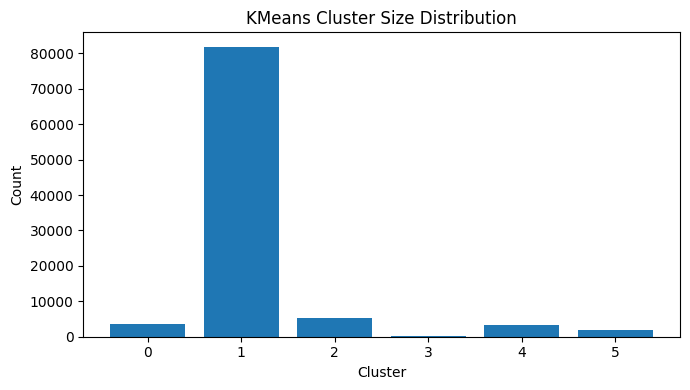

125

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
spark=(SparkSession.builder.appName('04_09_kmeans').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'clustering'/'kmeans'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
df=spark.read.parquet(str(FEATURE_DIR/'clustering_fe')).select('customer_unique_id','features').dropna()
kmeans=KMeans(featuresCol='features',predictionCol='prediction',k=6,seed=42,maxIter=50)
m=kmeans.fit(df)
pred=m.transform(df)
sil=ClusteringEvaluator(featuresCol='features',predictionCol='prediction',metricName='silhouette').evaluate(pred)
metrics={'model_family':'clustering','model_name':'KMeans','silhouette':float(sil),'rows':df.count(),'k':6}
print(metrics)
display(pd.DataFrame([metrics]))
cluster_pdf=pred.groupBy('prediction').count().orderBy('prediction').toPandas()
if not cluster_pdf.empty:
    display(cluster_pdf)
    plt.figure(figsize=(7,4))
    plt.bar(cluster_pdf['prediction'].astype(str), cluster_pdf['count'])
    plt.title('KMeans Cluster Size Distribution')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'clustering_kmeans.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')